# 🌌 OJALA QSO Sample Selection

This notebook selects a QSO sample from the OJALA catalogue and provides:

1. Random examples of QSO J-PAS photo-spectra after user-defined magnitude and redshift cuts.
2. Redshift distribution of `Z_QSO`.
4. Export of the final QSO catalogue.

In [29]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.style.use("dark_background")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "lines.linewidth": 2.2,
    "axes.grid": False,
})

## ⚙️ User configuration
Adjust here the input catalogue, output path, and QSO selection cuts.

In [42]:
# ---------------------------------------------------------------------
# USER CONFIGURATION
# ---------------------------------------------------------------------
REPO_ROOT = Path.cwd().resolve()

INPUT_CATALOG = REPO_ROOT / "data" / "catalogues" / "JPAS_EDR_photometry_APER_COR_3_0_OJALA_catalog.csv"
OUTPUT_DIR = REPO_ROOT / "data" / "catalogues"

# Selection cuts
MAG_I_MIN = None          # Example: 16.0, or None to disable
MAG_I_MAX = 23.0
Z_QSO_MIN = None          # Example: 0.0, or None to disable
Z_QSO_MAX = None          # Example: 3.5, or None to disable
P_QSO_MIN = 0.95

MIN_VALID_JPAS_FILTERS = 54

# JPAS photometry prefix used to build the OJALA input features
JPAS_PHOT_PREFIX = "APER_COR_3_0"

# Column names
MAG_I_COL = "MAG_i"
P_QSO_COL = "P_QSO"
CLASS_COL = "CLASS"
Z_QSO_COL = "Z_QSO"

HALPHA_EW_COL = "HALPHA_6562_EW"
HBETA_EW_COL = "HBETA_4861_EW"
OIII_EW_COL = "OIII_5007_EW"
NII_EW_COL = "NII_6584_EW"

USE_CLASS_FILTER = True
CLASS_TARGET = "QSO"

# Plot settings
FIG_DPI = 180
POINT_SIZE = 12
ALPHA_SCATTER = 0.70
BINS_Z = 60
FIGSIZE = (8, 6)



# Visual inspection of random QSOs
N_RANDOM_QSO_EXAMPLES = 6
RANDOM_SEED = 42

## J-PAS filters and effective wavelengths

In [31]:
FILTER_JPAS = [
    "J0378", "J0390", "J0400", "J0410", "J0420", "J0430", "J0440", "J0450",
    "J0460", "J0470", "J0480", "J0490", "J0500", "J0510", "J0520", "J0530",
    "J0540", "J0550", "J0560", "J0570", "J0580", "J0590", "J0600", "J0610",
    "J0620", "J0630", "J0640", "J0650", "J0660", "J0670", "J0680", "J0690",
    "J0700", "J0710", "J0720", "J0730", "J0740", "J0750", "J0760", "J0770",
    "J0780", "J0790", "J0800", "J0810", "J0820", "J0830", "J0840", "J0850",
    "J0860", "J0870", "J0880", "J0890", "J0900", "J0910"
]

EFF_WAVE_JPAS = {band: float(band[1:]) for band in FILTER_JPAS}

## 🧰 Helper functions

In [32]:
def ensure_output_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)


def get_jpas_input_columns(prefix):
    return [f"{prefix}_{filt}" for filt in FILTER_JPAS]


def validate_required_columns(df, required_columns):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError("Missing required columns in the catalogue:\n" + "\n".join(missing))


def count_valid_jpas_filters(df, jpas_columns):
    return df[jpas_columns].notna().sum(axis=1)


def finite_mask(*arrays):
    mask = np.ones(len(arrays[0]), dtype=bool)
    for arr in arrays:
        arr = np.asarray(arr)
        mask &= np.isfinite(arr)
    return mask


def smart_limits(values, pad_frac=0.08, qlow=0.01, qhigh=0.99, fallback=(-1, 1)):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        return fallback

    vmin = np.nanquantile(arr, qlow)
    vmax = np.nanquantile(arr, qhigh)

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return fallback

    if vmax <= vmin:
        delta = 0.5 if vmax == vmin else abs(vmax - vmin)
        return (vmin - delta, vmax + delta)

    pad = pad_frac * (vmax - vmin)
    return (vmin - pad, vmax + pad)

In [36]:
def apply_qso_selection(
    df,
    mag_i_col,
    p_qso_col,
    z_qso_col,
    jpas_columns,
    mag_i_min=None,
    mag_i_max=None,
    z_qso_min=None,
    z_qso_max=None,
    p_qso_min=0.0,
    min_valid_jpas_filters=0,
    use_class_filter=False,
    class_col=None,
    class_target="QSO",
):
    selected = df.copy()

    valid_filter_count = count_valid_jpas_filters(selected, jpas_columns)
    selected["N_VALID_JPAS_FILTERS"] = valid_filter_count

    mask = np.ones(len(selected), dtype=bool)

    mag_i = pd.to_numeric(selected[mag_i_col], errors="coerce")
    z_qso = pd.to_numeric(selected[z_qso_col], errors="coerce")
    p_qso = pd.to_numeric(selected[p_qso_col], errors="coerce")

    p_star = pd.to_numeric(selected['P_STAR'], errors="coerce")

    mask &= mag_i.notna().values
    mask &= z_qso.notna().values
    mask &= p_qso.notna().values

    if mag_i_min is not None:
        mask &= mag_i.values >= mag_i_min
    if mag_i_max is not None:
        mask &= mag_i.values < mag_i_max

    if z_qso_min is not None:
        mask &= z_qso.values >= z_qso_min
    if z_qso_max is not None:
        mask &= z_qso.values < z_qso_max

    mask &= p_qso.values >= p_qso_min
    
    mask &= selected["N_VALID_JPAS_FILTERS"].values >= min_valid_jpas_filters

    
    if use_class_filter and class_col is not None and class_col in selected.columns:
        mask &= selected[class_col].astype(str).values == class_target

    return selected.loc[mask].copy()

## 📥 Load the catalogue

In [34]:
ensure_output_dir(OUTPUT_DIR)

print("Reading catalogue...")
df = pd.read_csv(INPUT_CATALOG)

jpas_columns = get_jpas_input_columns(JPAS_PHOT_PREFIX)

required_columns = [
    MAG_I_COL,
    P_QSO_COL,
    Z_QSO_COL,
    HALPHA_EW_COL,
    HBETA_EW_COL,
    OIII_EW_COL,
    NII_EW_COL,
] + jpas_columns

if USE_CLASS_FILTER:
    required_columns.append(CLASS_COL)

validate_required_columns(df, required_columns)

print(f"Number of objects in catalogue: {len(df):,}")
print(f"Number of columns in catalogue: {len(df.columns):,}")

Reading catalogue...
Number of objects in catalogue: 675,672
Number of columns in catalogue: 317


## ✂️ Apply QSO selection

In [37]:
qso_df = apply_qso_selection(
    df=df,
    mag_i_col=MAG_I_COL,
    p_qso_col=P_QSO_COL,
    z_qso_col=Z_QSO_COL,
    jpas_columns=jpas_columns,
    mag_i_min=MAG_I_MIN,
    mag_i_max=MAG_I_MAX,
    z_qso_min=Z_QSO_MIN,
    z_qso_max=Z_QSO_MAX,
    p_qso_min=P_QSO_MIN,
    min_valid_jpas_filters=MIN_VALID_JPAS_FILTERS,
    use_class_filter=USE_CLASS_FILTER,
    class_col=CLASS_COL,
    class_target=CLASS_TARGET,
)

print(f"Selected QSO objects: {len(qso_df):,}")
qso_df.head()

Selected QSO objects: 1,388


,TILE_ID,NUMBER,ALPHA_J2000,DELTA_J2000,CLASS_STAR,FWHM_WORLD,KRON_RADIUS,A_WORLD,B_WORLD,R_EFF,...,FLUX_HBETA_ERR,FLUX_OIII5007,FLUX_OIII5007_ERR,FLUX_NII6584,FLUX_NII6584_ERR,HA_HB_RATIO,L_HALPHA_CORR,LOGSFR_HA,LOGSFR_HA_ERR,N_VALID_JPAS_FILTERS
2212,9611,51043,246.028137,43.818043,0.875000,0.000278,3.500000,0.000102,0.000100,1.579804,...,1.996141e-16,1.862942e-16,1.558103e-16,5.994101e-17,5.668233e-17,2.783289,7.897292e+42,1.795105,0.465671,54
4356,9611,51235,246.149587,43.815725,0.011353,0.000862,4.199656,0.000197,0.000176,2.806262,...,5.987127e-17,1.360742e-16,9.485492e-17,4.444435e-17,2.999294e-17,2.255575,6.783072e+41,0.729053,0.863420,54
4588,9611,53440,246.166178,43.780637,0.772461,0.000281,3.500000,0.000106,0.000104,1.653343,...,6.545517e-16,1.155863e-15,6.183311e-16,8.062417e-16,2.965464e-16,3.963935,4.624524e+43,2.562694,0.970270,54
4861,9611,40730,246.183328,43.994541,0.929199,0.000284,3.500000,0.000108,0.000105,1.669125,...,5.899941e-16,1.070454e-15,5.024795e-16,9.059392e-16,2.352204e-16,3.862690,6.741942e+43,2.726412,0.820509,54
5355,9611,37975,246.218782,44.044550,0.751953,0.000356,3.500000,0.000091,0.000089,1.399595,...,1.662983e-17,7.991798e-17,4.949855e-17,1.033256e-17,3.912344e-18,9.775024,5.883563e+43,2.667268,1.047844,54


## 🖼️ Random QSO J-PAS photo-spectra

In [38]:
REF_EMISSION_LINES = {
    r"[OII]": 372.709,
    r"H$\beta$": 486.133,
    r"[OIII]": 500.684,
    r"H$\alpha$": 656.280,
    r"MgII": 279.8,
    r"CIII]": 190.9,
    r"CIV": 154.9,
    r"Ly$\alpha$": 121.6,
}


def plot_panel_jpas_qso(ax, row, jpas_columns, ylim=None, prefix=JPAS_PHOT_PREFIX):
    z = row.get(Z_QSO_COL, np.nan)
    mag_i = row.get(MAG_I_COL, np.nan)
    p_qso = row.get(P_QSO_COL, np.nan)

    band_names = [col.replace(f"{prefix}_", "") for col in jpas_columns]
    waves = np.array([EFF_WAVE_JPAS[b] for b in band_names], dtype=float)

    vals = []
    errs = []
    for col in jpas_columns:
        vals.append(row.get(col, np.nan))
        errs.append(row.get(f"{col}_ERR", 0.0))

    vals = np.asarray(vals, dtype=float)
    errs = np.asarray(errs, dtype=float)

    valid = np.isfinite(waves) & np.isfinite(vals)

    if valid.sum() == 0:
        ax.text(0.5, 0.5, "No valid J-PAS photometry", ha="center", va="center")
        ax.set_axis_off()
        return

    norm = mcolors.Normalize(vmin=350, vmax=920)
    cmap = plt.get_cmap("turbo")
    colors = cmap(norm(waves))

    for i in range(len(waves)):
        if np.isfinite(vals[i]):
            ax.errorbar(
                waves[i],
                vals[i],
                yerr=errs[i] if np.isfinite(errs[i]) else 0.0,
                fmt="o",
                ecolor=colors[i],
                markerfacecolor=colors[i],
                markeredgecolor="white",
                markeredgewidth=0.5,
                markersize=12,
                elinewidth=1.4,
                zorder=10,
            )

    ax.plot(waves[valid], vals[valid], color="white", alpha=0.35, linewidth=1.2, zorder=2)

    if np.isfinite(z):
        ymin_p, ymax_p = ylim if ylim is not None else (np.nanmin(vals[valid]), np.nanmax(vals[valid]))
        for name, l_rest in REF_EMISSION_LINES.items():
            l_obs = l_rest * (1.0 + z)
            if 350 < l_obs < 920:
                ax.axvline(x=l_obs, color="gray", linestyle="--", linewidth=1.8, alpha=0.8, zorder=1)
                y_text = ymin_p + 0.08 * (ymax_p - ymin_p)
                ax.text(
                    l_obs, y_text, name,
                    rotation=90, color="white", fontsize=11,
                    va="bottom", ha="center", backgroundcolor="black"
                )

    fontsize1 = 16
    ax.text(0.04, 0.92, "QSO", transform=ax.transAxes, color="white", fontweight="bold", fontsize=fontsize1)
    ax.text(0.04, 0.82, f"z = {z:.3f}" if np.isfinite(z) else "z = nan", transform=ax.transAxes, fontsize=fontsize1)
    ax.text(0.56, 0.92, f"$i$ = {mag_i:.2f}" if np.isfinite(mag_i) else "$i$ = nan", transform=ax.transAxes, fontsize=fontsize1)
    ax.text(0.56, 0.82, f"P_QSO = {p_qso:.3f}" if np.isfinite(p_qso) else "P_QSO = nan", transform=ax.transAxes, fontsize=fontsize1)

    ax.set_xlim(350, 920)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel(r"$\lambda$ [nm]")
    ax.set_ylabel("Normalized Flux")
    ax.grid(False)

QSOs available after strict cuts: 561


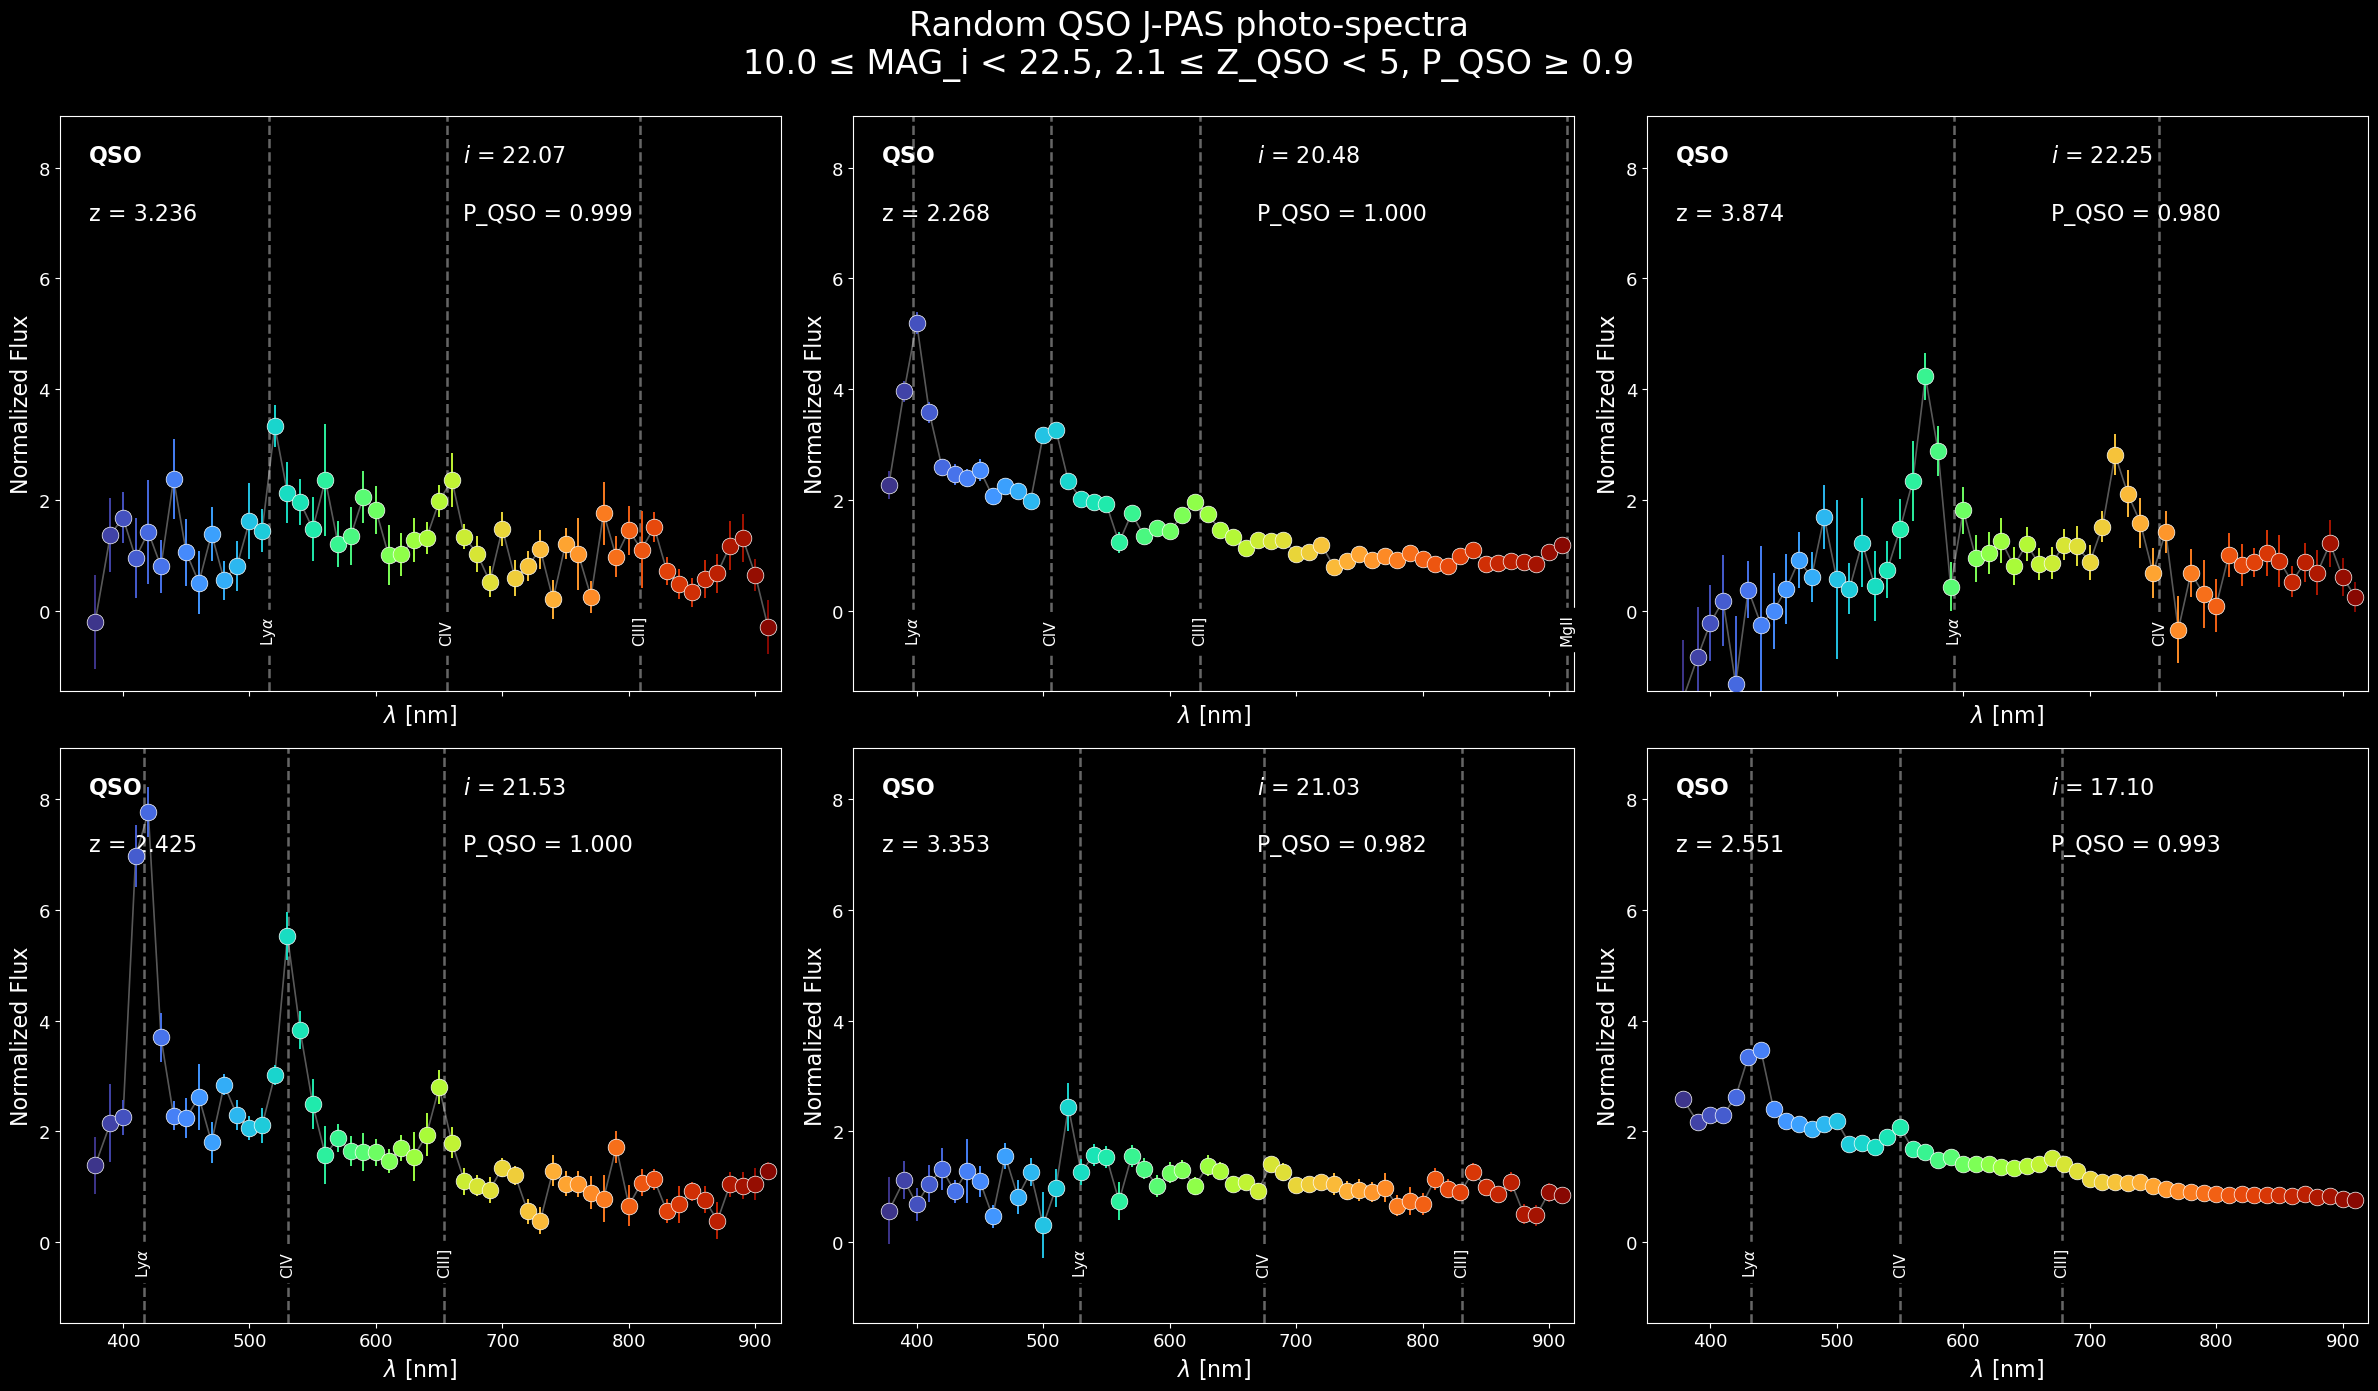

In [39]:
# ---------------------------------------------------------------------
# Extra-strict cuts only for the random QSO examples
# ---------------------------------------------------------------------
EXAMPLE_MAG_I_MIN = 10.0
EXAMPLE_MAG_I_MAX = 22.5

EXAMPLE_Z_QSO_MIN = 2.1
EXAMPLE_Z_QSO_MAX = 5

EXAMPLE_P_QSO_MIN = 0.9
RANDOM_SEED = 3

# Build a stricter subsample for visualization
plot_candidates = qso_df.copy()

mag_i_ex = pd.to_numeric(plot_candidates[MAG_I_COL], errors="coerce")
z_qso_ex = pd.to_numeric(plot_candidates[Z_QSO_COL], errors="coerce")
p_qso_ex = pd.to_numeric(plot_candidates[P_QSO_COL], errors="coerce")

mask_examples = np.isfinite(mag_i_ex) & np.isfinite(z_qso_ex) & np.isfinite(p_qso_ex)
mask_examples &= (mag_i_ex >= EXAMPLE_MAG_I_MIN) & (mag_i_ex < EXAMPLE_MAG_I_MAX)
mask_examples &= (z_qso_ex >= EXAMPLE_Z_QSO_MIN) & (z_qso_ex < EXAMPLE_Z_QSO_MAX)
mask_examples &= (p_qso_ex >= EXAMPLE_P_QSO_MIN)

plot_candidates = plot_candidates.loc[mask_examples].copy()

print(f"QSOs available after strict cuts: {len(plot_candidates):,}")

if len(plot_candidates) == 0:
    print("No QSOs satisfy the strict example cuts. Please relax the conditions.")
else:
    n_examples = min(N_RANDOM_QSO_EXAMPLES, len(plot_candidates))
    plot_df = plot_candidates.sample(n=n_examples, random_state=RANDOM_SEED).copy()

    ncols = 3
    nrows = int(np.ceil(n_examples / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(24, 7 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    all_vals = plot_df[jpas_columns].values.flatten()
    all_vals = all_vals[np.isfinite(all_vals)]
    ylim = (np.min(all_vals) * 0.9, np.max(all_vals) * 1.15) if len(all_vals) > 0 else None

    for i, ax in enumerate(axes):
        if i >= len(plot_df):
            ax.set_axis_off()
            continue

        row = plot_df.iloc[i]

        plot_panel_jpas_qso(
            ax=ax,
            row=row,
            jpas_columns=jpas_columns,
            ylim=ylim,
            prefix=JPAS_PHOT_PREFIX,
        )

    fig.suptitle(
        f"Random QSO J-PAS photo-spectra\n"
        f"{EXAMPLE_MAG_I_MIN} ≤ MAG_i < {EXAMPLE_MAG_I_MAX}, "
        f"{EXAMPLE_Z_QSO_MIN} ≤ Z_QSO < {EXAMPLE_Z_QSO_MAX}, "
        f"P_QSO ≥ {EXAMPLE_P_QSO_MIN}",
        fontsize=24,
        y=0.995
    )
    plt.tight_layout()
    plt.show()

## 📊 Redshift distribution of Z_QSO


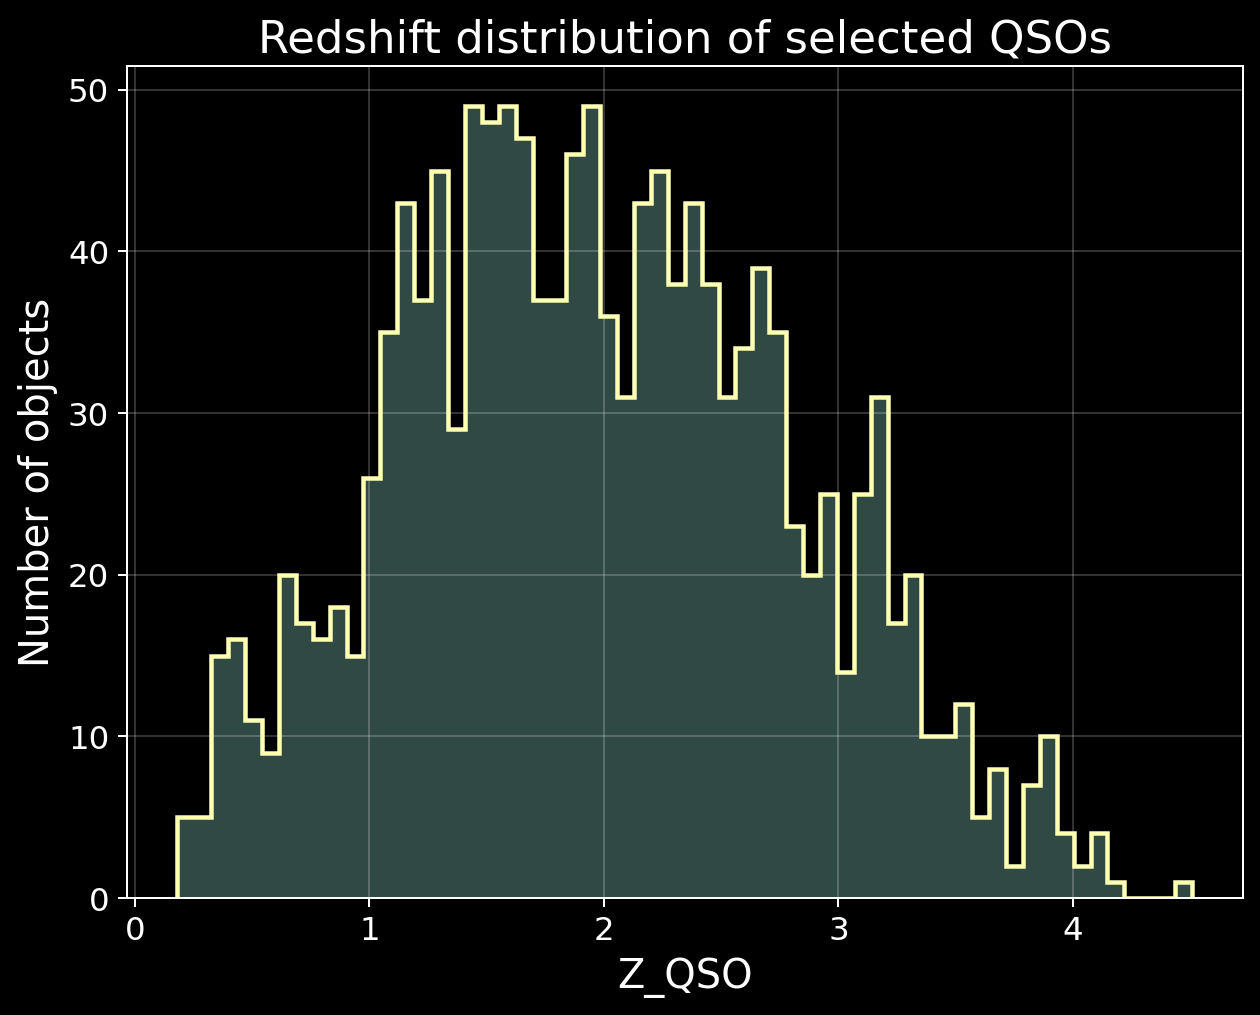

In [40]:
z_qso = pd.to_numeric(qso_df[Z_QSO_COL], errors="coerce").values
mask_z = np.isfinite(z_qso)

fig, ax = plt.subplots(figsize=FIGSIZE, dpi=FIG_DPI)

if mask_z.sum() == 0:
    ax.text(0.5, 0.5, "No valid Z_QSO values found.", ha="center", va="center")
    ax.set_axis_off()
else:
    bins = np.linspace(np.nanmin(z_qso[mask_z]), np.nanmax(z_qso[mask_z]), BINS_Z + 1)
    ax.hist(z_qso[mask_z], bins=bins, histtype="stepfilled", alpha=0.35)
    ax.hist(z_qso[mask_z], bins=bins, histtype="step", linewidth=1.8)

    ax.set_xlabel("Z_QSO")
    ax.set_ylabel("Number of objects")
    ax.set_title("Redshift distribution of selected QSOs")
    ax.grid(True, alpha=0.2)

plt.show()

## 💾 Save the QSO catalogue

In [ ]:
output_subcatalog = OUTPUT_DIR / "QSO_catalog.csv"
galaxy_df.to_csv(output_subcatalog, index=False)
print(f"Saved: {output_subcatalog}")